## Question 3

In [1]:
## import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_curve, auc)
from sklearn.preprocessing import StandardScaler

In [2]:
## import data

df = pd.read_csv('spambase/spambase.data', header=None)

columns = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam'
]

df.columns = columns

In [3]:
## Split data

X = df.drop(columns="spam")
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

## Question 3.1

In [4]:
## Scale data

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [9]:
## Build knn classifier  and use cross validation to select optimal k

print(f"{'k':<6} {'Accuracy':<12} {'Error':<12} {'Precision':<12} {'Recall'}")

cv_results = []
for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='accuracy')
    acc  = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='precision').mean()
    rec  = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='recall').mean()
    err  = 1 - acc
    cv_results.append((k, acc, err, prec, rec))
    print(f"{k:<6} {acc:<12.4f} {err:<12.4f} {prec:<12.4f} {rec:.4f}")

best_k = min(cv_results, key=lambda x: x[2])[0]
print(f"\nBest k: {best_k}")

k      Accuracy     Error        Precision    Recall
1      0.8959       0.1041       0.8693       0.8679
2      0.8841       0.1159       0.9178       0.7762
3      0.9017       0.0983       0.8825       0.8672
4      0.8945       0.1055       0.9161       0.8070
5      0.9020       0.0980       0.8948       0.8525
6      0.8968       0.1032       0.9169       0.8129
7      0.9006       0.0994       0.8950       0.8481
8      0.8925       0.1075       0.9122       0.8056
9      0.9017       0.0983       0.9008       0.8445
10     0.8945       0.1055       0.9079       0.8158
11     0.8971       0.1029       0.8966       0.8364
12     0.8948       0.1052       0.9094       0.8151
13     0.8957       0.1043       0.8967       0.8320
14     0.8925       0.1075       0.9029       0.8158
15     0.8983       0.1017       0.8956       0.8408
16     0.8945       0.1055       0.9061       0.8180
17     0.8980       0.1020       0.8985       0.8364
18     0.8933       0.1067       0.9077       

## Question 3.2

In [11]:
## Build all three models (knn using best k from 3.1)

lr  = LogisticRegression(max_iter=1000)
lda = LinearDiscriminantAnalysis()
knn = KNeighborsClassifier(n_neighbors=best_k)

lr.fit(X_train_s,  y_train)
lda.fit(X_train_s, y_train)
knn.fit(X_train_s, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [12]:
## Analyze results from each model

def report_metrics(name, model, X, y):
    y_pred = model.predict(X)
    acc  = accuracy_score(y, y_pred)
    err  = 1 - acc
    prec = precision_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    print(f"  {name:<25} Acc={acc:.4f}  Err={err:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")

print("Training Set")
for name, model in [('Logistic Regression', lr), ('LDA', lda), (f'kNN (k={best_k})', knn)]:
    report_metrics(name, model, X_train_s, y_train)

print("\nTesting Set")
for name, model in [('Logistic Regression', lr), ('LDA', lda), (f'kNN (k={best_k})', knn)]:
    report_metrics(name, model, X_test_s, y_test)

Training Set
  Logistic Regression       Acc=0.9296  Err=0.0704  Prec=0.9262  Rec=0.8929
  LDA                       Acc=0.8846  Err=0.1154  Prec=0.9135  Rec=0.7821
  kNN (k=5)                 Acc=0.9330  Err=0.0670  Prec=0.9275  Rec=0.9010

Testing Set
  Logistic Regression       Acc=0.9279  Err=0.0721  Prec=0.9400  Rec=0.8711
  LDA                       Acc=0.8966  Err=0.1034  Prec=0.9534  Rec=0.7733
  kNN (k=5)                 Acc=0.9123  Err=0.0877  Prec=0.9106  Rec=0.8600


## Analysis

First looking at results from the test set, kNN produces the best accuracy, error precision (by very little), and recall. Across the board kNN, with a k value of 5, produces optimal statistics in each category on the training data. On testing data, Logistic Regression has the best accuracy and recall, and lowest error, while LDA has the best precision. This shows how kNN applies the best to training data, but is not as effective when it comes to introducing new data to classify. Logistic Regression worked the best here when classifying new data, getting the best accuracy and lowest error. Logistic Regression also has the closest metrics between training and testing, showing that it is the best performing model overall. LDA is the worst performing model overall, not having the best metric in anything except precision on testing. Overall, all models perform fairly well.

## Question 3.3

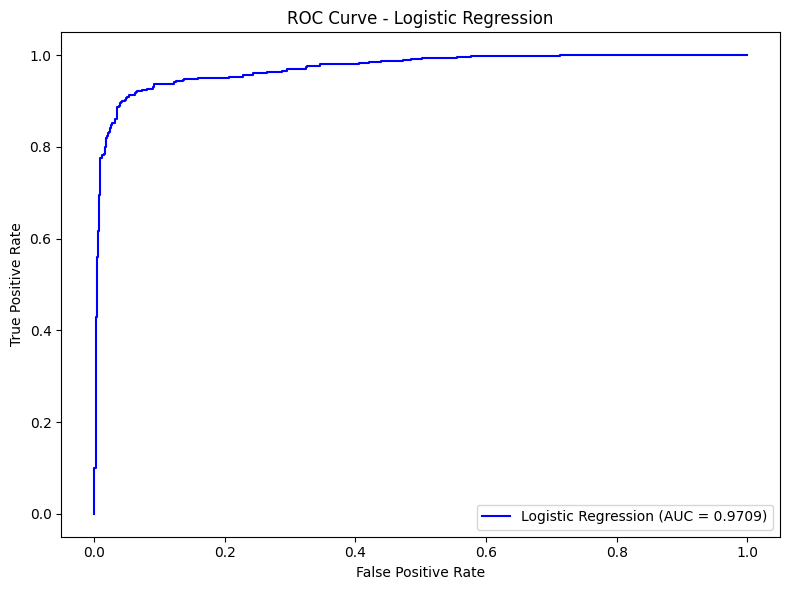

AUC: 0.9709


In [30]:
## Create ROC Curve and print AUC metric for logistic regression on test data

y_prob_lr = lr.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_score = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

## Question 3.4

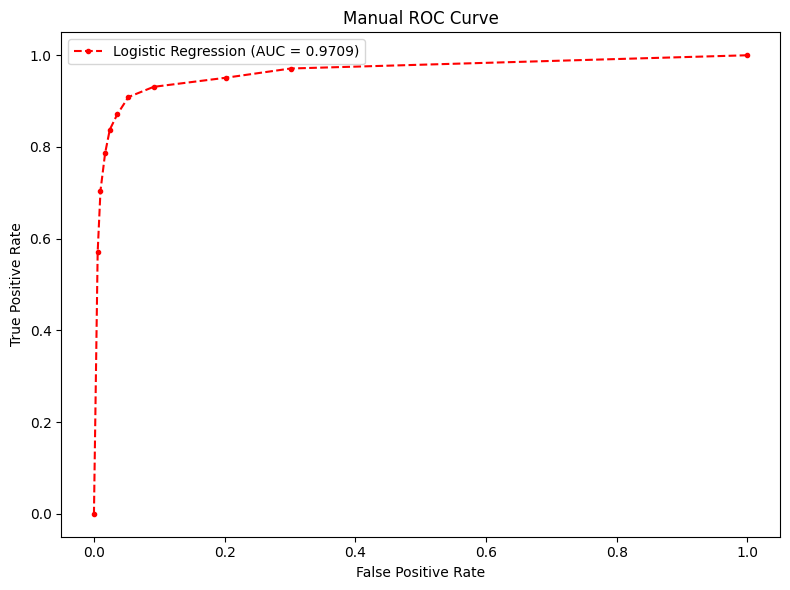

AUC: 0.9709


In [32]:
## Manually create ROC Curve

thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fprs, tprs = [], []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    tp = np.sum((y_pred_t == 1) & (y_test == 1))
    fp = np.sum((y_pred_t == 1) & (y_test == 0))
    tn = np.sum((y_pred_t == 0) & (y_test == 0))
    fn = np.sum((y_pred_t == 0) & (y_test == 1))
    tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

auc_score = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='red', linestyle='--', marker='o', markersize=3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Manual ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

## Analysis

The package ROC curve and manual ROC curve are pretty similar, even the AUC score is the same for both. The main difference is that our manual curve is smoother since it has less points. A way to increase both the similarities of both and the accuracy of the manual curve would be to add more threshold values, adding more points to the curve and making it blockier, but more accurate and closer to the package curve.